# Getting Started — DSA 2026 S2 Assignment

This notebook introduces the key concepts and dataset for the assignment. Work through it before starting the assignment questions.

**Contents:**
1. Key Concepts
2. Loading the Database
3. Table Overview
4. Joining Tables
5. Exploring the Data
6. Setting Up Your AI Log

## 1. Key Concepts

Before working with the dataset, you need to understand four concepts that underpin the assignment.

### Cumulative Abnormal Returns (CARs)

An **abnormal return** is the difference between a stock's actual return on a given day and the return you would have *expected* based on the stock's historical relationship with the broader market. If a stock normally moves 1.2× the market, and the market rises 1% on a day when the stock rises 5%, the abnormal return is approximately 5% − 1.2% = 3.8%. This isolates the company-specific effect from general market movements.

A **cumulative abnormal return (CAR)** sums abnormal returns over a short window around an event — in this dataset, the three trading days [−1, 0, +1] centred on the 8-K filing date. The CAR captures the market's total reaction to the news, including any information leakage on the day before and any delayed reaction the day after.

The CARs in this dataset were estimated using a **market model**: for each stock, the model regresses the stock's daily returns against the market index over a 120-day estimation window that ends before the event window, producing an alpha (intercept) and beta (market sensitivity). The abnormal return on each event-window day is then: actual return minus (alpha + beta × market return).

**Interpreting CARs:**
- A CAR of **+0.15** means the stock gained approximately 15% *more* than the market model predicted over the three-day window — the market reacted positively to the news.
- A CAR of **−0.20** means the stock lost approximately 20% relative to expectations — a strongly negative reaction.
- CARs near zero mean the announcement had little detectable impact on the stock price.
- `car_3day` has been **winsorised** at the 1st and 99th percentiles, meaning the most extreme values have been pulled in to those cut-offs. The untreated values are in `car_3day_raw`. Any range or percentile you quote from `car_3day` is therefore capped at the tails by construction, and it is worth saying so when you report it. Use `car_3day` for modelling and for summary statistics; use `car_3day_raw` only when the tails are themselves the object of study.

### Clinical Trial Phases

Drug development proceeds through a series of clinical trial phases, each with a different purpose and risk profile:

| Phase | Purpose | Typical Size | Key Risk |
|-------|---------|-------------|----------|
| **Phase 1** | Safety and dosing in healthy volunteers or patients | 20–80 | Is the drug safe enough to continue? |
| **Phase 2** | Efficacy signal and dose optimisation in patients | 100–300 | Does the drug show a meaningful treatment effect? |
| **Phase 3** | Confirmatory efficacy and safety in a large patient population | 300–3,000+ | Does the drug work well enough to gain regulatory approval? |

Phase 3 trials are the most consequential for share prices because they are the last major hurdle before regulatory submission. A Phase 3 failure typically destroys the commercial value of the drug program, while success opens the path to market. Phase 2 readouts can also move prices significantly, but the market often discounts them because Phase 2 success does not guarantee Phase 3 success (historically, only about 30–40% of drugs that succeed in Phase 2 go on to succeed in Phase 3).

### 8-K Filings and the SEC

In the United States, publicly listed companies are required to file an **8-K form** with the Securities and Exchange Commission (SEC) when a material event occurs — that is, an event that a reasonable investor would consider important in making an investment decision. Clinical trial results for pharmaceutical and biotechnology companies are typically considered material events, and companies disclose them via 8-K filings, often on the same day as or the day after a press release.

The dataset contains the full text of approximately 3,800 8-K filings that disclosed clinical trial results. These filings vary enormously in length and detail — some are brief press releases embedded in the 8-K wrapper, while others contain detailed statistical results, subgroup analyses, and management commentary.

### Market Expectations and 'Priced In' Effects

A critical concept for this assignment: **the market reaction to an announcement depends not on whether the result is objectively good or bad, but on how it compares to what the market already expected.**

If the market already assigns a high probability to a trial succeeding (e.g., because earlier data was strong, or the drug's mechanism is well-validated), then a positive result may produce only a modest price increase — the success was largely "priced in." Conversely, if the market expected failure and the trial succeeds, the price reaction can be dramatic.

This creates an important asymmetry in the dataset:
- **Positive trials with small or negative CARs** — the market expected success, so confirmation adds little new information. In some cases, the market may even sell on the news ("buy the rumour, sell the fact") if the results, while positive, are slightly below expectations.
- **Negative trials with large negative CARs** — trial failures are harder to anticipate and often produce sharp, sudden drops. The market rarely fully prices in failure because companies selectively disclose positive interim signals.

This means that the LLM-classified outcome (positive, negative, etc.) and the sign of the CAR will not always agree. **This is not necessarily a classification error** — it may reflect market expectations. You will need to consider this when evaluating the LLM classifications in Question 1a.

## 2. Loading the Database

The dataset is a SQLite database, `ctgov.db`, supplied zipped as `ctgov.db.zip` — 40 MB zipped, 146 MB unpacked. The setup cell below finds it, unzips it if the zip is all it finds, and opens a connection. It can only do that once the file is somewhere this session can reach, and how you arrange that depends on where you are working.

### Working locally

Put `ctgov.db.zip` in the same folder as this notebook. Nothing else to do — run the setup cell.

### Working in Colab

A Colab session starts with an empty disk and wipes it when the session ends, so the database has to be brought in. There are two ways, and the first is worth the small amount of extra effort.

**Option A — keep it in Google Drive (recommended).** Upload `ctgov.db.zip` to your Drive once, either at the top level of *My Drive* or into a folder there called `DSA`. Then run the Drive cell below and authorise when Colab asks. The setup cell will find it by itself, and it is still there the next time you open the notebook — you do the upload once, not once a week.

**Option B — upload it each session.** Run this in a cell and pick `ctgov.db.zip` from your machine:

```python
from google.colab import files
files.upload()
```

That is a 40 MB upload, so allow a few minutes, and you repeat it every time the session restarts. Fine for a single sitting; Option A is better if you are coming back to this over several weeks.

If the setup cell raises `FileNotFoundError`, neither the database nor the zip was found — come back to this section.

In [1]:
# Colab only. Run this before the setup cell if you keep ctgov.db.zip in Google Drive.
# It does nothing when you are working locally, so it is safe to run either way.
import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    print("\nDrive mounted. The setup cell looks for ctgov.db.zip in:")
    print("    /content/drive/MyDrive/          (the top level of My Drive)")
    print("    /content/drive/MyDrive/DSA/      (a folder called DSA inside it)")
    print("Put the file in either one, then run the setup cell.")
else:
    print("Not running on Colab - nothing to mount.")
    print("Put ctgov.db.zip in the same folder as this notebook, then run the setup cell.")


Not running on Colab - nothing to mount.
Put ctgov.db.zip in the same folder as this notebook, then run the setup cell.


In [5]:
import os, sys, sqlite3, zipfile
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules


def open_database(name="ctgov.db", archive="ctgov.db.zip"):
    """Locate the database and return its path, extracting the zip if that is all there is.

    Behaves the same locally and on Colab. This runs before sqlite3.connect() on purpose:
    connect() silently creates an empty database when the file is missing, so a missing
    file would otherwise show up much later as 'no such table'.
    """
    places = [os.getcwd()]
    if IN_COLAB:
        places += ["/content", "/content/drive/MyDrive", "/content/drive/MyDrive/DSA"]

    for d in places:
        db = os.path.join(d, name)
        if os.path.isfile(db):
            return db
        archive_path = os.path.join(d, archive)
        if os.path.isfile(archive_path):
            # Unpack to the session disk rather than back into Drive: writing 146 MB to
            # Drive is slow and consumes your quota, and the session copy reads faster.
            target = "/content" if IN_COLAB and d.startswith("/content/drive") else d
            print("Extracting %s to %s ..." % (archive, target))
            try:
                with zipfile.ZipFile(archive_path) as z:
                    z.extractall(target)
            except zipfile.BadZipFile:
                raise RuntimeError(
                    "%s could not be opened. The most likely cause is an interrupted\n"
                    "download - the file should be about 40 MB. Delete it, download it\n"
                    "again, and re-run this cell." % archive_path)
            db = os.path.join(target, name)
            if os.path.isfile(db):
                return db

    looked = "\n  ".join(places)
    if IN_COLAB:
        raise FileNotFoundError(
            "%s not found. Looked in:\n  %s\n\n"
            "Nothing has been loaded yet - see section 2 above, which sets out both routes.\n"
            "In short, either mount your Drive and keep the file in MyDrive:\n"
            "    from google.colab import drive; drive.mount('/content/drive')\n"
            "or upload it for this session only:\n"
            "    from google.colab import files; files.upload()\n\n"
            "Uploading is fine for a single sitting; Drive survives a disconnect." % (name, looked)
        )
    raise FileNotFoundError(
        "%s not found. Looked in:\n  %s\n\n"
        "Put %s (or %s) beside this notebook, or change directory to the folder holding it."
        % (name, looked, name, archive)
    )


if tuple(int(x) for x in matplotlib.__version__.split(".")[:2]) < (3, 9):
    print("Warning: matplotlib %s. This notebook needs 3.9 or newer (the box plot below uses\n"
          "tick_labels=). Run:  pip install -U 'matplotlib>=3.9'" % matplotlib.__version__)

try:
    import sentence_transformers  # noqa: F401  (checked here, used in Question 1c)
except ImportError:
    print("Question 1c asks for word or sentence embeddings, which need a library this\n"
          "environment does not have yet. Before you start Question 1, run:\n"
          "    pip install sentence-transformers      (~2 GB, it brings torch with it)\n"
          "On Colab, put a ! in front of that and run it in a cell.")

DB_PATH = open_database()
conn = sqlite3.connect(DB_PATH)
print("Connected to %s (%.0f MB) - %s environment."
      % (os.path.basename(DB_PATH), os.path.getsize(DB_PATH) / 1e6,
         "Colab" if IN_COLAB else "local"))

# A part-downloaded database opens without complaint and then fails much later with
# something unhelpful like "no such table". Check it here instead, while the cause
# is still obvious.
_integrity = conn.execute("PRAGMA quick_check(1)").fetchone()[0]
_n_tables = conn.execute("SELECT COUNT(*) FROM sqlite_master WHERE type='table'").fetchone()[0]
if _integrity != "ok" or _n_tables != 12:
    print("\nThis database does not look complete: %s, %d tables, expected 12.\n"
          "Delete ctgov.db and ctgov.db.zip, download again, and re-run this cell."
          % (_integrity, _n_tables))
else:
    print("%d tables, integrity check ok." % _n_tables)

Question 1c asks for word or sentence embeddings, which need a library this
environment does not have yet. Before you start Question 1, run:
    pip install sentence-transformers      (~2 GB, it brings torch with it)
On Colab, put a ! in front of that and run it in a cell.
Extracting ctgov.db.zip to c:\Users\Nebula PC\OneDrive\Desktop\DSA\DSA_26S2 ...
Connected to ctgov.db (146 MB) - local environment.
12 tables, integrity check ok.


## 3. Table Overview

The cell below lists every table in the database with its row and column counts. The data dictionary (`data_dictionary.xlsx`) describes what each column means.

In [6]:
# List all tables with row counts
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")
tables = cursor.fetchall()

table_info = []
for (name,) in tables:
    cursor.execute(f"SELECT COUNT(*) FROM [{name}]")
    count = cursor.fetchone()[0]
    cursor.execute(f"PRAGMA table_info([{name}])")
    n_cols = len(cursor.fetchall())
    table_info.append({"Table": name, "Rows": f"{count:,}", "Columns": n_cols})

pd.DataFrame(table_info).style.hide(axis="index")

Table,Rows,Columns
asclepius_readouts,3,25
asclepius_scenario_filings,9,7
consensus_outcomes,"4,539",11
event_fda_features,"2,482",10
event_study_enriched,"2,615",53
event_study_results,"2,615",17
fda_drug_match,"1,495",6
filing_summary,"1,905",8
filing_text,"3,794",2
stock_prices,"486,378",4


The key tables you will use most often are:

| Table | Description |
|-------|-------------|
| `event_study_enriched` | **Main analytical table.** One row per trial result, linking the event study CAR to trial design features from ClinicalTrials.gov. This is the table you will use for most of your analysis. |
| `filing_text` | Full text of each 8-K filing. Join to `event_study_enriched` on `accession`. |
| `filing_summary` | One row per filing (deduplicates multi-drug filings). Useful when you need filing-level rather than drug-level analysis. |
| `studies` | Full ClinicalTrials.gov records for linked trials. Join via `study_event_link`. |
| `stock_prices` | Daily closing prices and volume for all tickers in the dataset, plus three index ETFs: SPY (S&P 500), XBI (SPDR S&P Biotech), and IBB (iShares Biotechnology). |
| `event_fda_features` | FDA approval features per event (application type, years since approval, company track record). |
| `fda_drug_match` | Drug-level FDA matching. `fda_matched` records whether the drug name could be matched to an FDA application at all — it is **not** an approval flag. Use `fda_approved` in `event_study_enriched` for approval status. |
| `consensus_outcomes` | Raw LLM classification outputs from both prompts, including the consensus logic. |

### Data model

The diagram below shows how the historical tables relate to each other. The main analytical table
(`event_study_enriched`) is a denormalised join of event study results, trial design features and FDA
data — you can do most of your analysis from this table alone. The other tables provide additional
detail when you need it (full filing text, raw LLM outputs, daily stock prices). Row and column counts
are in the table above; this diagram is about which key joins to which.

```
                          ┌─────────────────────┐
                          │   filing_text        │
                          │   PK: accession      │
                          └──────────┬───────────┘
                                     │ accession
                                     │
┌──────────────────────┐    ┌────────┴────────────┐    ┌─────────────────────┐
│ consensus_outcomes   │    │ event_study_enriched │    │ stock_prices        │
│ PK: accession +      ├────┤ Key: accession +     ├────┤ PK: ticker + date   │
│     drug_name        │    │   drug_name +        │    │                     │
│                      │    │   indication  *      │    │                     │
└──────────────────────┘    └──┬──────────┬────────┘    └─────────────────────┘
                               │          │
                  accession +  │          │ accession +
                  drug_name    │          │ drug_name
                               │          │
                ┌──────────────┴─┐    ┌───┴──────────────────┐
                │ filing_summary │    │ study_event_link     │
                │ PK: accession  │    │ PK: accession +      │
                └────────────────┘    │     drug_name        │
                                      └───────────┬──────────┘
                                                  │ nct_id
                                                  │
                                      ┌───────────┴──────────┐
                                      │ studies              │
                                      │ PK: nct_id           │
                                      └──────────────────────┘

┌──────────────────────┐    ┌────────────────────────┐
│ fda_drug_match       │    │ event_fda_features      │
│ PK: drug_name        │    │ PK: accession +         │
│                      │    │     drug_name           │
└──────────────────────┘    └────────────────────────┘

* (accession, drug_name) is nearly unique but not strictly so —
  a small number of pairs appear more than once where the same
  drug reported results for different indications in the same filing.

Join keys:
  event_study_enriched.accession       → filing_text.accession
  event_study_enriched.accession       → filing_summary.accession
  event_study_enriched.(accession, drug_name) → study_event_link
  event_study_enriched.(accession, drug_name) → event_fda_features
  event_study_enriched.drug_name       → fda_drug_match.drug_name
  study_event_link.nct_id              → studies.nct_id
  consensus_outcomes.accession         → event_study_enriched.accession

  event_study_enriched.ticker + DATE(event_date) → stock_prices.ticker + date
```

**One join needs care.** `event_study_enriched.event_date` is stored with a time component
(`2012-10-24 00:00:00`) while `stock_prices.date` is a plain date (`2012-10-24`). Joining them
directly on equality matches **nothing at all**, and returns an empty frame rather than an error.
Wrap the event date in `DATE()`:

```sql
JOIN stock_prices s
  ON s.ticker = e.ticker AND s.date = DATE(e.event_date)
```

There is also a tenth historical table, `event_study_results`, not drawn above. It holds the event
study output on its own — one row per event with `alpha`, `beta`, `car_3day`, `car_3day_raw` and the
estimation-window diagnostics. `event_study_enriched` is that table joined to trial design and FDA
features, so for most purposes you can work from the enriched table and ignore this one.

For most analyses, start with `event_study_enriched` and join other tables as needed.

Two further tables exist for **Question 4a only** and are not part of the diagram above. They are
fictional — built so you have a lookalike readout to apply your pipeline to — and share no keys with
the historical tables. Do not join them to `event_study_enriched` or anything else above.

```
┌──────────────────────────────┐
│ asclepius_readouts           │
│ PK: readout_id               │
└──────────────────────────────┘
                 │ readout_id
                 │
┌──────────────────────────────┐
│ asclepius_scenario_filings   │
│ PK: accession                │
└──────────────────────────────┘
```


In [7]:
# Preview the main analytical table.
# SELECT * is fine here - 2,615 rows. It stops being free on the wider tables: the same
# query against filing_text pulls 3,794 documents with a median length near 19,000
# characters, which is well over 70 MB into memory. Name the columns you need there.
enriched = pd.read_sql("SELECT * FROM event_study_enriched", conn)
print(f"event_study_enriched: {len(enriched):,} rows, {len(enriched.columns)} columns")
print(f"\nColumn names:\n{list(enriched.columns)}")
enriched.head(3)

event_study_enriched: 2,615 rows, 53 columns

Column names:
['accession', 'ticker', 'event_date', 'drug_name', 'phase', 'phase_clean', 'indication', 'outcome', 'outcome_group', 'consensus_type', 'alpha', 'beta', 'car_3day', 'ar_day0', 'n_est_days', 'n_evt_days', 'car_3day_raw', 'nct_id', 'match_method', 'match_confidence', 'brief_title', 'official_title', 'brief_summary', 'eligibility_criteria', 'intervention_names', 'intervention_types', 'conditions', 'keywords', 'enrollment', 'enrollment_type', 'phases', 'allocation', 'intervention_model', 'masking', 'primary_purpose', 'n_arm_groups', 'n_interventions', 'n_primary_outcomes', 'n_secondary_outcomes', 'lead_sponsor', 'lead_sponsor_class', 'overall_status', 'has_dmc', 'start_date', 'primary_completion', 'completion_date', 'countries', 'n_locations', 'fda_approved', 'fda_approval_date', 'disclosure_lag_days', 'lag_quality', 'market_cap']


,accession,ticker,event_date,drug_name,phase,phase_clean,indication,outcome,outcome_group,consensus_type,...,start_date,primary_completion,completion_date,countries,n_locations,fda_approved,fda_approval_date,disclosure_lag_days,lag_quality,market_cap
0,0000059478-12-000018,LLY,2012-10-24 00:00:00,solanezumab,Phase 3,Phase 3,Alzheimer's disease (mild-to-moderate),mixed-negative,Negative,agree,...,2009-05,2012-04,2012-04,Argentina|Brazil|Canada|Japan|United States,85,False,NaN,192.0,clean,5.860149e+10
1,0000059478-12-000018,LLY,2012-10-24 00:00:00,dulaglutide,Phase 3,Phase 3,Type 2 diabetes,positive,Positive,agree,...,2008-08,2011-06,2012-07,Canada|France|Germany|India|Mexico|Poland|Puer...,99,True,20061016,497.0,clean,5.860149e+10
2,0000059478-12-000018,LLY,2012-10-24 00:00:00,ramucirumab (IMC-1121B),Phase 3,Phase 3,Metastatic gastric cancer,positive,Positive,agree,...,2009-08,2012-07,2015-12,Argentina|Australia|Bosnia and Herzegovina|Bra...,161,True,20140421,101.0,clean,5.860149e+10


**A note on two columns above:** `overall_status` and `fda_approved` reflect the trial/application status as of when this database was built, not as of the event date — using them as predictive features risks look-ahead leakage, since they may encode information that was not yet known at the time of the announcement.

## 4. Joining Tables

The tables in the database are linked by common keys. Here are the most important joins.

### 4.1 Enriched events → Filing text

Each row in `event_study_enriched` has an `accession` column (the SEC filing identifier). Use this to retrieve the original 8-K text from `filing_text`.

In [8]:
# Join enriched events to filing text
example = pd.read_sql("""
    SELECT e.accession, e.ticker, e.drug_name, e.outcome_group, e.car_3day,
           e.phase_clean, e.indication,
           SUBSTR(f.filing_text, 1, 300) AS filing_excerpt
    FROM event_study_enriched e
    JOIN filing_text f ON e.accession = f.accession
    WHERE e.outcome_group = 'Positive' AND e.car_3day BETWEEN 0.05 AND 0.30
          AND e.phase_clean = 'Phase 3'
    LIMIT 3
""", conn)
example

,accession,ticker,drug_name,outcome_group,car_3day,phase_clean,indication,filing_excerpt
0,0000059478-18-000186,LLY,galcanezumab,Positive,0.073354,Phase 3,Episodic cluster headache,8-K 1 q22018earnings8-kdoc.htm 8-K Q2 2018 EA...
1,0000059478-21-000168,LLY,tirzepatide,Positive,0.073777,Phase 3,Type 2 diabetes (vs insulin glargine in patien...,EX-99.1 2 q221lillysalesandearningsp.htm EX-9...
2,0000078003-25-000111,PFE,Talzenna (talazoparib),Positive,0.066610,Phase 3,Metastatic castration-resistant prostate cance...,EX-99 2 pfe-03302025xex99.htm EX-99 Document ...


### 4.2 Enriched events → FDA features

The `event_fda_features` table provides FDA approval features for each event. Join on `accession` and `drug_name`.

**Watch the encoding on `fda_approved`.** Both tables carry a column of that name and they are stored differently: `event_fda_features.fda_approved` is an integer `0`/`1`, while `event_study_enriched.fda_approved` and `studies.fda_approved` are the *strings* `'True'` and `'False'`. A join like the one below returns both under one name, so a filter written for one will silently match nothing on the other.

In [9]:
# Join enriched events to FDA features
fda_example = pd.read_sql("""
    SELECT e.ticker, e.drug_name, e.outcome_group, e.car_3day,
           ef.fda_application_type, ef.fda_n_prior_approvals,
           ef.fda_years_since_approval, ef.company_n_fda_approved
    FROM event_study_enriched e
    JOIN event_fda_features ef 
        ON e.accession = ef.accession AND e.drug_name = ef.drug_name
    WHERE ef.fda_application_type IS NOT NULL
    LIMIT 5
""", conn)
fda_example

,ticker,drug_name,outcome_group,car_3day,fda_application_type,fda_n_prior_approvals,fda_years_since_approval,company_n_fda_approved
0,LLY,dulaglutide,Positive,-0.021124,BLA,0,NaN,36
1,LLY,ramucirumab (IMC-1121B),Positive,-0.021124,BLA,0,NaN,36
2,LLY,prasugrel (Effient),Negative,-0.021124,NDA,5,3.29,36
3,LLY,Alimta (pemetrexed),Negative,-0.021124,NDA,15,8.72,36
4,LLY,ramucirumab,Negative,0.019335,BLA,0,NaN,36


### 4.3 Enriched events → ClinicalTrials.gov records

The `event_study_enriched` table already contains the most useful trial design fields (enrollment, masking, allocation, etc.) merged in from the `studies` table. If you need the full 77-column ClinicalTrials.gov record, join via `study_event_link`:

In [10]:
# Join via study_event_link to the full studies table
study_join = pd.read_sql("""
    SELECT e.accession, e.drug_name, sel.nct_id, sel.match_method, sel.match_confidence,
           s.overall_status, s.study_type, s.enrollment
    FROM event_study_enriched e
    JOIN study_event_link sel 
        ON e.accession = sel.accession AND e.drug_name = sel.drug_name
    JOIN studies s ON sel.nct_id = s.nct_id
    LIMIT 5
""", conn)
study_join

,accession,drug_name,nct_id,match_method,match_confidence,overall_status,study_type,enrollment
0,0000059478-12-000018,solanezumab,NCT00905372,pass2_title_search,high,COMPLETED,INTERVENTIONAL,1000
1,0000059478-12-000018,dulaglutide,NCT00734474,pass2_title_search,high,COMPLETED,INTERVENTIONAL,1202
2,0000059478-12-000018,ramucirumab (IMC-1121B),NCT00917384,same_sponsor,high,COMPLETED,INTERVENTIONAL,355
3,0000059478-12-000018,pomaglumetad methionil (mGlu2/3),NCT01487083,same_sponsor,high,TERMINATED,INTERVENTIONAL,282
4,0000059478-12-000018,prasugrel (Effient),NCT00699998,same_sponsor,high,COMPLETED,INTERVENTIONAL,9326


## 5. Exploring the Data

### 5.1 CAR distribution by outcome group

The chart below shows how cumulative abnormal returns differ across LLM-classified outcome groups.

Read it carefully, because the separation is narrower than it first looks. The *means* differ by about 19 percentage points (+1.6% for positive outcomes against -17.5% for negative), but the *medians* differ by only about 4 (-0.5% against -4.9%). Almost all of the gap lives in the left tail of the negative group: a minority of severe crashes drags its mean down a long way. The box plot hides outliers and the histogram is clipped to +/-0.5, so both understate that tail. Section 5.7 returns to this.

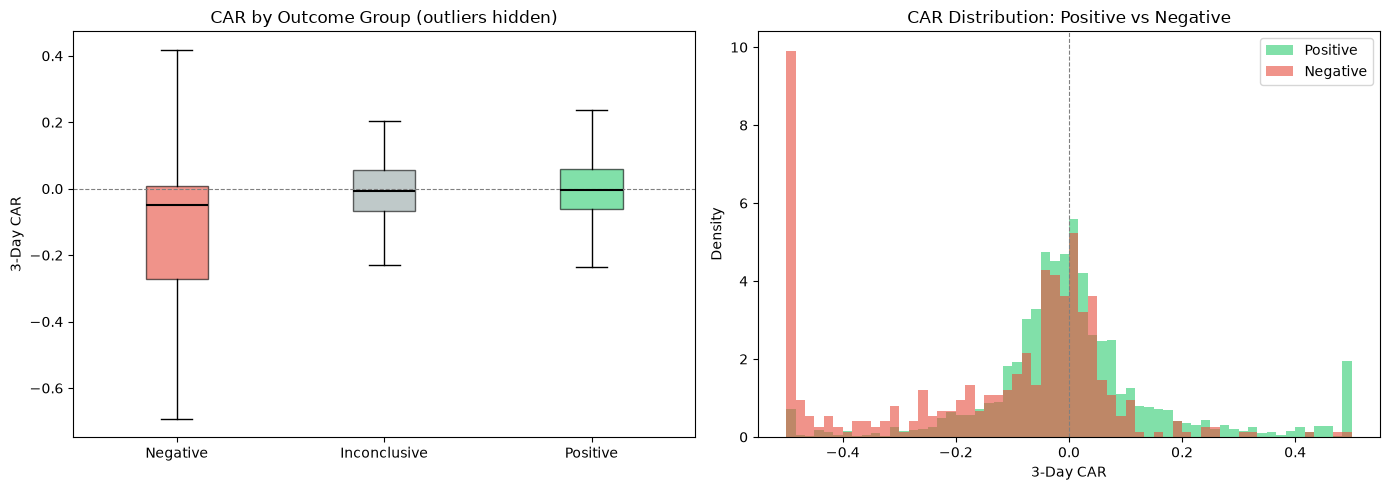

Summary statistics by outcome group:


,count,mean,std,min,50%,max
outcome_group,,,,,,
Inconclusive,181.0,0.0029,0.1429,-0.6805,-0.0063,0.9450
Negative,448.0,-0.1745,0.2858,-0.8423,-0.0492,0.6404
Positive,1944.0,0.0160,0.2013,-0.8423,-0.0052,0.9450


In [11]:
# CAR distribution by outcome group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
order = ["Negative", "Inconclusive", "Positive"]
data_groups = [enriched[enriched["outcome_group"] == g]["car_3day"].dropna() for g in order]
bp = axes[0].boxplot(data_groups, tick_labels=order, patch_artist=True, showfliers=False,
                     medianprops=dict(color="black", linewidth=1.5))
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("3-Day CAR")
axes[0].set_title("CAR by Outcome Group (outliers hidden)")

# Histogram — positive vs negative
axes[1].hist(enriched[enriched["outcome_group"] == "Positive"]["car_3day"].clip(-0.5, 0.5),
             bins=60, alpha=0.6, color="#2ecc71", label="Positive", density=True)
axes[1].hist(enriched[enriched["outcome_group"] == "Negative"]["car_3day"].clip(-0.5, 0.5),
             bins=60, alpha=0.6, color="#e74c3c", label="Negative", density=True)
axes[1].axvline(0, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("3-Day CAR")
axes[1].set_ylabel("Density")
axes[1].set_title("CAR Distribution: Positive vs Negative")
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("Summary statistics by outcome group:")
enriched.groupby("outcome_group")["car_3day"].describe()[["count", "mean", "std", "min", "50%", "max"]].round(4)

### 5.2 CAR by trial phase

Later-phase failures produce the largest negative reactions, because more value is at stake. In this dataset Phase 2 and Phase 3 negative outcomes are of a similar size (mean CAR -18.3% and -18.0% respectively) and Phase 1 results are much smaller.

Two cautions when you read the table below. The Phase 1 negative cell rests on **7 observations** and its mean is positive -- that is noise, not a finding, and it supports no inference. And the filter keeps only Phase 1-3, which is 2,466 of the 2,573 classified events, so 107 events are excluded here and your counts will not tie to the totals elsewhere.

In [12]:
# Mean CAR by phase and outcome group
phase_outcome = enriched[enriched["phase_clean"].isin(["Phase 1", "Phase 2", "Phase 3"])].copy()
pivot = phase_outcome.groupby(["phase_clean", "outcome_group"])["car_3day"].agg(["mean", "count"]).round(4)
pivot = pivot.unstack("outcome_group")
print("Mean CAR and count by phase × outcome group:")
pivot

Mean CAR and count by phase × outcome group:


mean                          count                  
outcome_group Inconclusive Negative Positive Inconclusive Negative Positive
phase_clean                                                                
Phase 1             0.0046   0.0117  -0.0008           60        7      297
Phase 2             0.0073  -0.1825   0.0050           69      166      696
Phase 3             0.0035  -0.1795   0.0309           35      264      872

### 5.3 Company size

The `market_cap` column gives pre-event market capitalisation in USD. The cell below reports how complete it is.

In [13]:
# Market cap summary
mcap = enriched["market_cap"].dropna()
print(f"Events with market_cap: {len(mcap):,} / {len(enriched):,}")
print(f"Median: ${mcap.median():,.0f}   Mean: ${mcap.mean():,.0f}")
print(f"Min:    ${mcap.min():,.0f}   Max:  ${mcap.max():,.0f}")
print(f"\nMedian market cap by outcome group:")
print(enriched.groupby("outcome_group")["market_cap"].median().map("${:,.0f}".format))

Events with market_cap: 2,526 / 2,615
Median: $679,672,988   Mean: $24,253,604,928
Min:    $16,911   Max:  $1,046,653,260,434

Median market cap by outcome group:
outcome_group
Inconclusive    $223,137,356
Negative        $321,931,441
Positive        $897,097,801
Name: market_cap, dtype: str


### 5.4 Reading an 8-K filing

Here is an example of what the 8-K filing text looks like. This is a Phase 3 result for reproxalap (ticker: ALDX), which was classified as positive and had a CAR of approximately +28%.

In [14]:
# Read an example 8-K filing
example_accession = "0001193125-19-085920"  # ALDX reproxalap Phase 3
filing = pd.read_sql(
    "SELECT filing_text FROM filing_text WHERE accession = ?",
    conn, params=[example_accession]
)
text = filing["filing_text"].iloc[0]
print(f"Filing length: {len(text):,} characters")
print(f"\n--- First 2,000 characters ---\n")
print(text[:2000])

Filing length: 156,340 characters

--- First 2,000 characters ---

 8-K 1 d699950d8k.htm 8-K 8-K UNITED STATES SECURITIES AND EXCHANGE COMMISSION Washington, D.C. 20549 FORM 8-K CURRENT REPORT Pursuant to Section 13 or 15(d) of the Securities Exchange Act of 1934 Date of Report (Date of earliest event reported): March 26, 2019 (March 25, 2019) ALDEYRA THERAPEUTICS, INC. (Exact name of Registrant as specified in its charter) Delaware 001-36332 20-1968197 (State or other jurisdiction of incorporation) (Commission File No.) (IRS Employer Identification No.) 131 Hartwell Avenue, Suite 320 Lexington, MA 02421 (Address of principal executive offices and zip code) Registrant’s telephone number, including area code: (781) 761-4904 Not Applicable (Former Name or Former Address, if Changed Since Last Report) Check the appropriate box below if the Form 8-K filing is intended to simultaneously satisfy the filing obligation of the registrant under any of the following provisions: ☐ Written communic

**Before you build text features from `filing_text`:** some filings run to well over 100,000 characters, as above, but sentence-transformer and other transformer-based models read only a fixed, fairly short window (often a few hundred tokens) before truncating silently. If you use `filing_text` to build sentence embeddings or similar features, check the model's `max_seq_length` against your documents' actual token counts before trusting the result --- see Supplementary Reading Section S6 ("Documents longer than the model's input window") for the check and the options for handling documents that exceed it.

### 5.5 Stock prices around an event

The `stock_prices` table contains daily closing prices and volume. Here we plot the stock price for a company around the date of a trial announcement, showing how the price reacted.

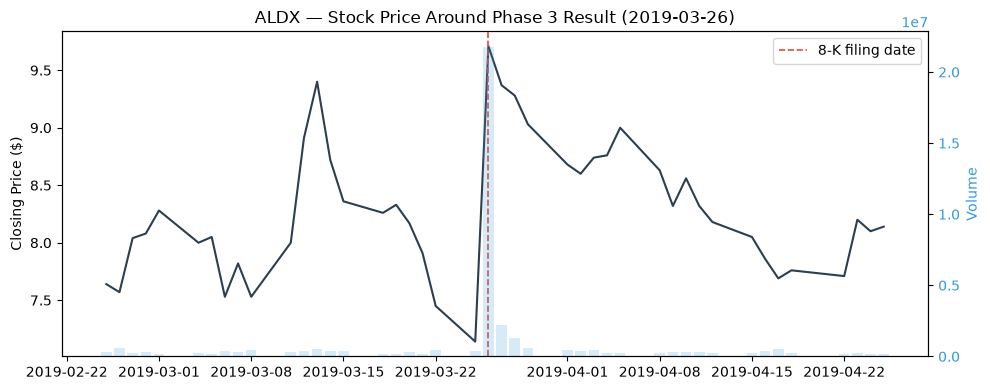

In [15]:
# Plot stock price around a trial announcement
# Example: ALDX reproxalap positive Phase 3 result on 2019-03-26
event_ticker = "ALDX"
event_date = "2019-03-26"

prices = pd.read_sql("""
    SELECT date, close, volume FROM stock_prices
    WHERE ticker = ? AND date BETWEEN date(?, '-30 days') AND date(?, '+30 days')
    ORDER BY date
""", conn, params=[event_ticker, event_date, event_date])
prices["date"] = pd.to_datetime(prices["date"])

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(prices["date"], prices["close"], color="#2c3e50", linewidth=1.5)
ax1.axvline(pd.Timestamp(event_date), color="#e74c3c", linestyle="--", linewidth=1.2, label="8-K filing date")
ax1.set_ylabel("Closing Price ($)")
ax1.set_title(f"{event_ticker} — Stock Price Around Phase 3 Result ({event_date})")
ax1.legend()

# Add volume bars
ax2 = ax1.twinx()
ax2.bar(prices["date"], prices["volume"], alpha=0.2, color="#3498db", width=0.8)
ax2.set_ylabel("Volume", color="#3498db")
ax2.tick_params(axis="y", labelcolor="#3498db")

plt.tight_layout()
plt.show()

### 5.6 Multi-drug filings

Some 8-K filings report results for multiple drugs in a single filing. When this happens, the same accession number (and the same CAR) appears multiple times in `event_study_enriched` — once per drug. The `filing_summary` table provides one row per filing with a `primary_outcome` classification and a `has_mixed_outcomes` flag.

In [16]:
# Multi-drug filings
multi = pd.read_sql("""
    SELECT fs.accession, fs.ticker, fs.n_drugs, fs.outcomes, 
           fs.primary_outcome, fs.has_mixed_outcomes, fs.car_3day
    FROM filing_summary fs
    WHERE fs.n_drugs > 1
    ORDER BY fs.n_drugs DESC
    LIMIT 10
""", conn)
print(f"Filings with multiple drugs: {pd.read_sql('SELECT COUNT(*) FROM filing_summary WHERE n_drugs > 1', conn).iloc[0,0]}")
print(f"Total filings: {pd.read_sql('SELECT COUNT(*) FROM filing_summary', conn).iloc[0,0]}")
multi

Filings with multiple drugs: 435
Total filings: 1905


,accession,ticker,n_drugs,outcomes,primary_outcome,has_mixed_outcomes,car_3day
0,0000882095-13-000022,GILD,11,"positive, positive, positive, positive, positi...",positive,0,0.067130
1,0000078003-15-000003,PFE,10,"positive, negative, positive, negative, positi...",negative,1,0.001047
2,0000078003-16-000102,PFE,9,"positive, positive, positive, positive, positi...",positive,0,-0.035830
3,0001104659-16-092322,ABBV,9,"positive, positive, positive, positive, positi...",positive,0,-0.073906
4,0000078003-14-000027,PFE,8,"positive, positive, positive, positive, negati...",negative,1,-0.046349
5,0001104659-18-028825,MRK,8,"positive, positive, positive, positive, positi...",negative,1,-0.026678
6,0000059478-26-000008,LLY,7,"positive, positive, positive, positive, positi...",positive,0,-0.014052
7,0000078003-22-000098,PFE,7,"positive, mixed-positive, mixed-positive, posi...",mixed-positive,0,0.014515
8,0000078003-25-000149,PFE,7,"positive, positive, mixed-positive, negative, ...",negative,1,0.003065
9,0001104659-21-056877,MRK,7,"positive, positive, positive, positive, positi...",positive,0,-0.034014


### 5.7 The 'priced in' effect in action

As discussed in Key Concepts, the sign of the CAR does not always match the LLM-classified outcome. Here we look at the proportion of "disagreements" — positive outcomes with negative CARs, and negative outcomes with positive CARs.

In [17]:
# Label-return disagreements
pos = enriched[enriched["outcome_group"] == "Positive"]
neg = enriched[enriched["outcome_group"] == "Negative"]

pos_neg_car = (pos["car_3day"] < 0).sum()
neg_pos_car = (neg["car_3day"] > 0).sum()

print(f"Positive outcomes with negative CAR: {pos_neg_car}/{len(pos)} ({pos_neg_car/len(pos):.1%})")
print(f"Negative outcomes with positive CAR: {neg_pos_car}/{len(neg)} ({neg_pos_car/len(neg):.1%})")
print(f"\nThese disagreements are not necessarily classification errors —")
print(f"they often reflect market expectations (see Key Concepts above).")

Positive outcomes with negative CAR: 1014/1944 (52.2%)
Negative outcomes with positive CAR: 135/448 (30.1%)

These disagreements are not necessarily classification errors —
they often reflect market expectations (see Key Concepts above).


### 5.8 A minimal cross-validation skeleton

Nothing above splits the data. Before you report any predictive result you will need a held-out evaluation, and the shape of that evaluation matters as much as the model inside it.

The rule the code below encodes: every step that *learns* something from the data — a median, a mean and standard deviation, a category encoding, a vocabulary — belongs inside the `Pipeline`, not in a block of tidying that runs beforehand. `cross_val_score` refits the whole pipeline once per fold, so anything inside it is recomputed from that fold's training rows alone. Anything you do to `X` before handing it over is fitted once, over every row, including the rows each fold is meant to be holding out. The score that comes back is then flattering rather than obviously broken, which is why this kind of leak tends to survive as far as the report.

`KFold` shuffles rows at random. Whether individual rows are the right unit to split on here is a separate question — Section 5.6 is a good place to start — and `cross_val_score` accepts `groups` alongside a grouped splitter if they are not.

In [18]:
# A minimal cross-validation skeleton
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

# Placeholders, not suggestions: beta and n_est_days are by-products of the
# event-study estimation window. Substitute the features you have chosen.
FEATURES = ["beta", "n_est_days"]
TARGET = "car_3day"

df = pd.read_sql(
    f"SELECT {', '.join(FEATURES)}, {TARGET} FROM event_study_enriched", conn
).dropna(subset=[TARGET])

X, y = df[FEATURES], df[TARGET]

pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # learns a median
    ("scale",  StandardScaler()),                   # learns a mean and a standard deviation
    ("model",  Ridge()),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2")

print(f"R2 by fold: {scores.round(3)}")
print(f"Mean R2:    {scores.mean():.3f}  (placeholder features, so the number means nothing)")

# The same evaluation done wrongly, for contrast:
#   X_ready = SimpleImputer(strategy="median").fit_transform(X)   # median taken over every row
#   X_ready = StandardScaler().fit_transform(X_ready)             # mean and sd taken over every row
#   cross_val_score(Ridge(), X_ready, y, cv=cv, scoring="r2")     # held-out rows already used

R2 by fold: [ 0.022 -0.    -0.002 -0.002  0.016]
Mean R2:    0.007  (placeholder features, so the number means nothing)


### A note on the outcome classifications

The `outcome_group` column in `event_study_enriched` (Positive, Negative, Inconclusive, plus rows left
null where classification was not possible) and the more granular `outcome` column were generated by an
LLM pipeline that read and classified the 8-K filing text. These classifications are derived from the
filing text itself — they represent what the filing *says* about the trial result, based on language
available at the time of the announcement. They are not post-hoc labels applied after observing the
market reaction.

The classification scheme has six categories — `positive`, `negative`, `mixed-positive`,
`mixed-negative`, `inconclusive` and `no_result` — but you will only see five of them in
`event_study_enriched`. A filing with no reported outcome has no event to study, so `no_result` rows
never enter that table at all. `no_result` accounts for roughly 37% of classifications across the full
pipeline, which means that if you are comparing classification against market reaction your effective
sample is around 58% of the classified *records* (these are drug-level, so one filing can produce
several), not the full dataset.

You will also find a handful of compound values such as `positive/negative` in the `outcome` column.
These are the rows where the two LLM prompts disagreed and the pipeline declined to resolve them: they
carry `flagged = 1` and `consensus_type = 'flagged_disagreement'`, and their `outcome_group` is null.
So anything you group by `outcome_group` is already clean, while `outcome` preserves which two labels
were in contention — which is worth looking at in Question 1.

When deciding which features to include in a predictive model, consider the **information timeline**:
what information is available at the time of the event? Features derived from the filing text reflect
pre-event information (the filing is published at or before the market reaction), while features
derived from the market reaction itself (e.g. event-day volume or the CAR) are concurrent or
post-event.

Don't expect a high R² from a model like this. Market reactions to clinical trial readouts are
inherently hard to predict, and R² for models built on this dataset typically lands somewhere around
0.08–0.14. Variation across modelling attempts in that range reflects genuine unpredictability rather
than a broken model. Substantially *more* than this is the result worth being suspicious of — an R²
well above the range is more often a sign of leakage than of a good model, which is what Question 3b
asks you to assess.


## 6. Setting Up Your AI Log

If you use AI tools, Question 5 requires the conversations themselves. Set this up before you start rather than at the end — conversations are hard to recover afterwards.

**'Recording your AI use.docx' is the instruction**: what to capture from each kind of tool, how to name the files, and what to submit. Two things it cannot tell you, because they depend on where you are working:

**Where to keep the folder.** `compile_ai_logs.py` looks for `ai_logs/` in the folder you run it from, so keep it beside the assignment notebook you will submit — not beside this one.

**If you work in Colab, do not keep it in the session.** Colab wipes `/content` when the runtime disconnects, so an `ai_logs/` folder there is gone by your next sitting. Keep it in your Drive instead (mount Drive, then work under `/content/drive/MyDrive/`), or download the folder before you close the session. Losing a conversation is not recoverable after the fact, which is why this is worth settling now rather than in September.

One thing worth having to hand: if a conversation could not be captured at all — a work tool blocked the export, a chat expired, you forgot — record that honestly in a short entry of your own. The cell below writes one, named the way the guidance requires.

In [19]:
# --- If a conversation could not be captured -------------------------------
# A work tool blocked the export, a temporary chat expired, history was cleared,
# or you simply forgot. None of that is a breach, provided you record it honestly.
# This writes a short note of your own into ai_logs/, named like any other log, so
# it is compiled and read alongside the real conversations.

import os
from datetime import date


def write_manual_note(qtag, topic, note, when=None, log_dir="ai_logs"):
    """Write a manual entry to ai_logs/ when a conversation could not be saved."""
    os.makedirs(log_dir, exist_ok=True)
    stamp = when or date.today().isoformat()          # or pass when="2026-08-14"
    path = os.path.join(log_dir, "%s_%s_%s.md" % (stamp, qtag, topic))
    with open(path, "w", encoding="utf-8") as f:
        f.write("# Manual entry - %s\n\n*%s. Written by me because the conversation "
                "itself could not be saved.*\n\n%s\n" % (topic.replace("-", " "), stamp, note))
    print("Wrote", path)
    return path


# Edit the tag, topic and text to describe what actually happened, then uncomment
# and run. Do not leave the example text in place - a log entry that misdescribes
# your own work is an integrity matter, not an untidy file.
#
# write_manual_note(
#     "Q1", "chatgpt-export-blocked",
#     "Used ChatGPT for about 15 minutes to talk through the stratified sample for Q1a. "
#     "My work account blocks copying transcripts out, so I could not save the exchange. "
#     "I asked how to stratify a small sample so that every outcome category appears, and "
#     "checked the answer against the Chapter 6 sampling material before using it."
# )


---

You're now ready to start the assignment. Remember:
- The **data dictionary** (`data_dictionary.xlsx`) describes every column in every table.
- The **methodology document** describes how the LLM classifications, event study, and trial linkage were produced.
- Use `conn.close()` when you're finished with the database, or keep the connection open throughout your notebook.
